<a href="https://colab.research.google.com/github/Mouna-R408/AI-Assignment/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

To load Python libraries required for data analysis and machine learning.

Libraries like NumPy, Pandas, Sklearn provide functions for data processing and model building.



In [11]:
from google.colab import files
uploaded = files.upload()


Saving insurance.csv to insurance.csv


To import the insurance dataset into the Python environment.

Allows us to read and access the data for further analysis.

In [13]:
import pandas as pd

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


To import the insurance dataset into the Python environment.

Allows us to read and access the data for further analysis.

In [14]:
#Understand the Dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


To check data types, number of rows, and columns in the dataset.

Helps identify missing values or incorrect data.

In [15]:
#missing values
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0



To check data types, number of rows, and columns in the dataset.

Helps identify missing values or incorrect data.




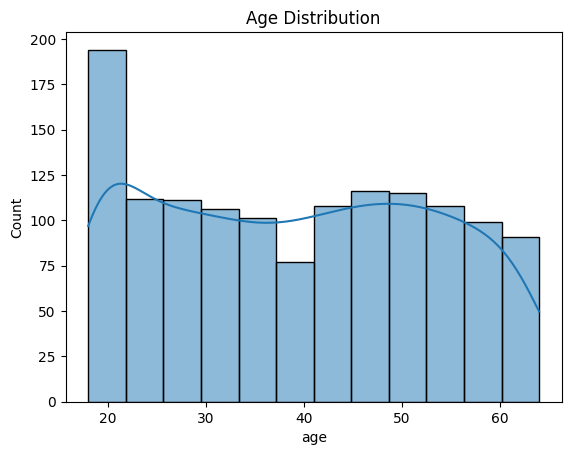

In [16]:
#Exploratory Data Analysis
#Age Distribution
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

To understand patterns and relationships between variables.

Visualizations help identify trends, distributions, and outliers.

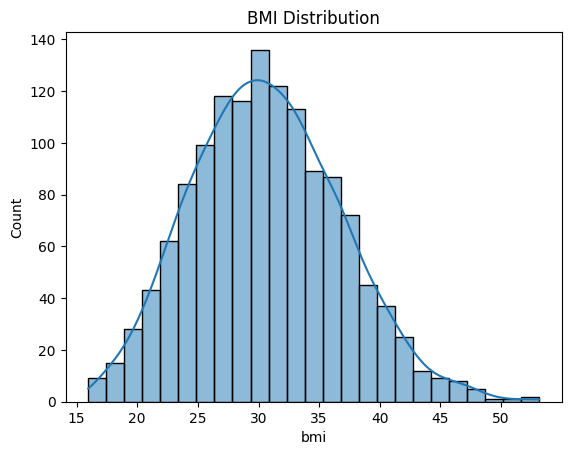

In [17]:
#BMI Distribution
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

To understand patterns and relationships between variables.

Visualizations help identify trends, distributions, and outliers.

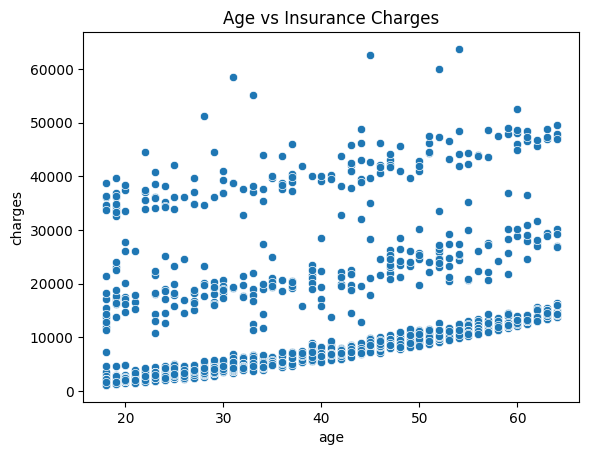

In [18]:
#Charges vs Age
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Insurance Charges")
plt.show()

To understand patterns and relationships between variables.

Visualizations help identify trends, distributions, and outliers.

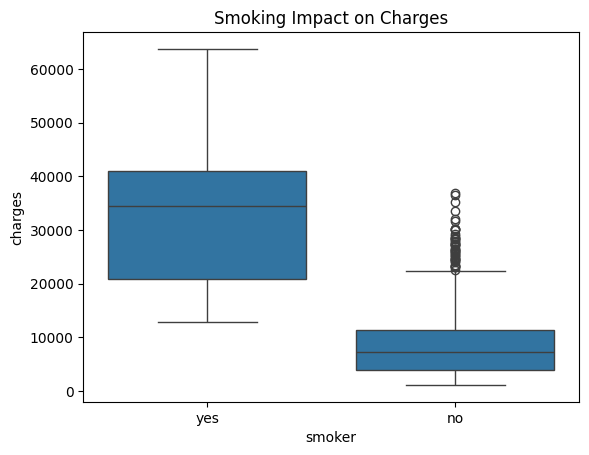

In [19]:
#Smoking Effect
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoking Impact on Charges")
plt.show()

To understand patterns and relationships between variables.

Visualizations help identify trends, distributions, and outliers.

In [20]:
#Data Preprocessing

#Encode Categorical Variables
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

To convert categorical data (sex, smoker, region) into numerical form.

Machine learning models require numeric input values.

In [21]:
#Normalize BMI
scaler = StandardScaler()
df[['bmi']] = scaler.fit_transform(df[['bmi']])

To scale BMI values into a standard range.

Improves model performance and training stability

In [22]:
#Define Features and Target
X = df.drop("charges", axis=1)
y = df["charges"]

To separate input variables (X) and output variable (y).

The model learns from features to predict the target (charges).

In [23]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

To divide data into training data and testing data.

Helps evaluate how well the model performs on unseen data

In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
RMSE: 5799.587091438356
MAE: 4186.508898366431
R2 Score: 0.7833463107364539


To predict insurance cost using a linear relationship between variables.

It is a simple and fast baseline regression model

In [25]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2 Score:", r2_rf)

Random Forest Results
RMSE: 4571.027176627287
MAE: 2527.698451164771
R2 Score: 0.8654141051672786


Combines multiple decision trees to improve prediction accuracy.

Reduces overfitting and handles complex relationships.

In [26]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("RMSE:", rmse_gb)
print("MAE:", mae_gb)
print("R2 Score:", r2_gb)

Gradient Boosting Results
RMSE: 4352.538932159728
MAE: 2447.951558054584
R2 Score: 0.8779726251291786


Builds models sequentially to reduce errors from previous models.

Often provides high accuracy for regression problems.

In [27]:
#Model Comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [rmse_lr, rmse_rf, rmse_gb],
    "MAE": [mae_lr, mae_rf, mae_gb],
    "R2 Score": [r2_lr, r2_rf, r2_gb]
})

results

,Model,RMSE,MAE,R2 Score
0,Linear Regression,5799.587091,4186.508898,0.783346
1,Random Forest,4571.027177,2527.698451,0.865414
2,Gradient Boosting,4352.538932,2447.951558,0.877973


Metrics like RMSE and MAE measure prediction errors.

Helps determine which model performs best.

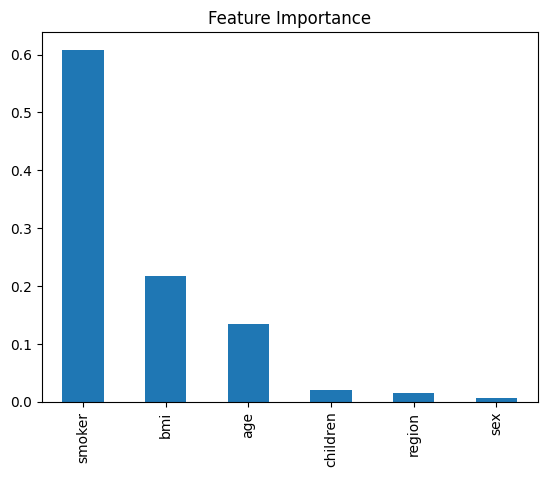

In [28]:
#Feature Importance
feature_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

feature_importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

To compare performance of all models in one table.

Helps select the best model for prediction.

In [29]:
sample = [[35, 1, 0.2, 2, 1, 3]]

prediction = rf.predict(sample)

print("Predicted Insurance Cost:", prediction[0])

Predicted Insurance Cost: 38668.30417949998


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


To test the trained model with new customer data.

Provides predicted insurance charges based on inputs.

In [30]:
# Calculate average insurance charges for smokers and non-smokers
avg_charges = df.groupby("smoker")["charges"].mean()

print("Average Insurance Charges:")
print(avg_charges)

Average Insurance Charges:
smoker
0     8434.268298
1    32050.231832
Name: charges, dtype: float64


To calculate the average insurance cost for smokers and non-smokers.

Helps quantitatively prove that smokers pay higher insurance charges.

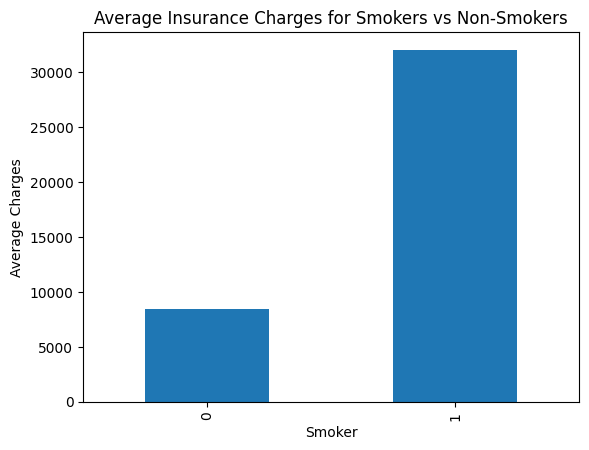

In [31]:
# Bar chart to compare average charges
avg_charges.plot(kind='bar')
plt.title("Average Insurance Charges for Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Average Charges")
plt.show()

To visualize the difference in insurance charges between smokers and non-smokers.

Helps identify distribution, median, and variation of charges for both groups